# Desafio 04 - Diagnostico de Diabetes

**Curso:** Algoritmos de Inteligência Artificial - Unimar

**Grupo:** 4   
**Dataset:** Pima Indians Diabetes Database  


---

## Objetivo

O objetivo deste trabalho e construir um modelo de classificacao capaz de prever se uma paciente tem diabetes com base em medicoes medicas. O dataset vem da comunidade Pima Indian e contem informacoes como nivel de glicose, pressao arterial, espessura da pele, insulina, IMC, entre outros

---

## Alunos:

* Alan Uesugui Uemura - RA: 2084808
* Julio Cesar Plaza - RA: 2046253
* Pedro Renat - RA: 2238778

---

## Importação das Bibliotecas

A seguir importamos todas as bibliotecas necessárias para o projeto: manipulação de dados (`numpy`, `pandas`), visualização (`matplotlib`, `seaborn`), modelagem (`sklearn`), análise estatística (`scipy`) e salvamento do modelo (`joblib`).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from scipy import stats

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score, GridSearchCV, learning_curve
)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report,
    ConfusionMatrixDisplay, precision_recall_curve, average_precision_score
)

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

print("Bibliotecas importadas com sucesso.")

Bibliotecas importadas com sucesso.


## Carregamento do Dataset

O dataset utilizado é o **Pima Indians Diabetes Database**, originalmente coletado pelo National Institute of Diabetes and Digestive and Kidney Diseases. Contém dados clínicos de 768 mulheres da população Pima Indian, com 8 variáveis preditoras e uma variável-alvo binária (`Outcome`: 0 = não-diabético, 1 = diabético).

In [2]:
df = pd.read_csv('../data/diabetes.csv')

print(f"Dataset carregado com {df.shape[0]} amostras e {df.shape[1]} colunas.")
print()
df.head(10)

Dataset carregado com 768 amostras e 9 colunas.



,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


---

# Etapa 1 — Análise Exploratória dos Dados (EDA)

Antes de qualquer modelagem, exploramos o dataset para entender sua estrutura, distribuição das classes, presença de valores ausentes disfarçados e relações entre variáveis. Essas informações guiam todas as decisões de pré-processamento.

In [3]:
print("Informacoes gerais do dataset:")
print(f"Dimensoes: {df.shape[0]} linhas x {df.shape[1]} colunas")
print()
print("Tipos de dados:")
print(df.dtypes)
print()
print("Estatisticas descritivas:")
df.describe().round(2)

Informacoes gerais do dataset:
Dimensoes: 768 linhas x 9 colunas

Tipos de dados:
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

Estatisticas descritivas:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00
mean,3.85,120.89,69.11,20.54,79.80,31.99,0.47,33.24,0.35
std,3.37,31.97,19.36,15.95,115.24,7.88,0.33,11.76,0.48
min,0.00,0.00,0.00,0.00,0.00,0.00,0.08,21.00,0.00
25%,1.00,99.00,62.00,0.00,0.00,27.30,0.24,24.00,0.00
50%,3.00,117.00,72.00,23.00,30.50,32.00,0.37,29.00,0.00
75%,6.00,140.25,80.00,32.00,127.25,36.60,0.63,41.00,1.00
max,17.00,199.00,122.00,99.00,846.00,67.10,2.42,81.00,1.00


A visualização inicial mostra que todas as 9 colunas são numéricas (`float64` ou `int64`), sem variáveis categóricas — o que simplifica o pré-processamento. O `describe()` revela que colunas como **Insulin** (média 79, mas mín = 0) e **SkinThickness** (média 20, mín = 0) possuem zeros que biologicamente são impossíveis, indicando **valores ausentes disfarçados** — tratados na próxima etapa.

### Distribuição das Classes

Verificamos se o dataset está balanceado — isso impacta diretamente a escolha das métricas de avaliação e a necessidade de tratamento do desbalanceamento.

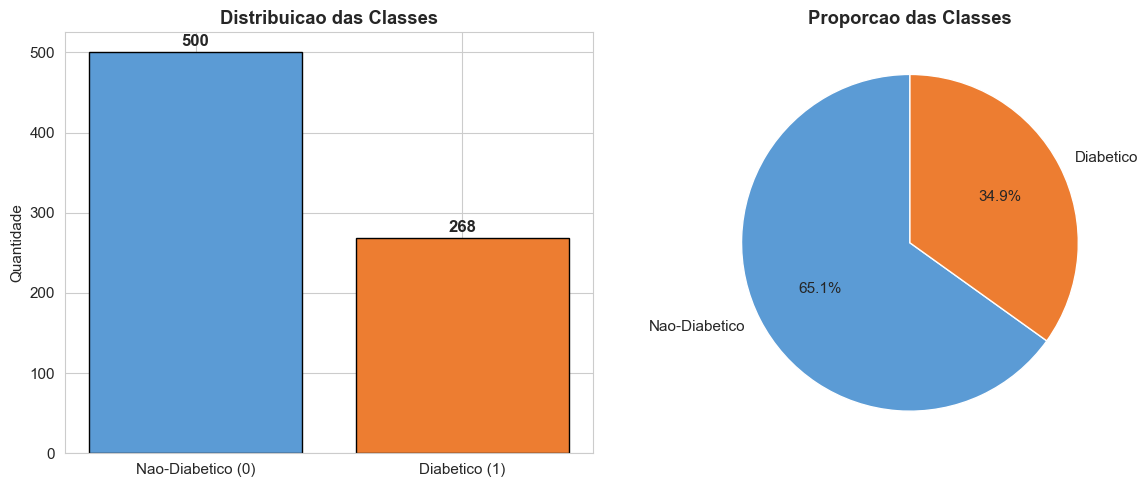

Classe 0 (Nao-Diabetico): 500 amostras (65.1%)
Classe 1 (Diabetico):     268 amostras (34.9%)


In [4]:
contagem = df['Outcome'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(['Nao-Diabetico (0)', 'Diabetico (1)'], contagem.values,
            color=['#5B9BD5', '#ED7D31'], edgecolor='black')
axes[0].set_title('Distribuicao das Classes', fontweight='bold')
axes[0].set_ylabel('Quantidade')
for i, v in enumerate(contagem.values):
    axes[0].text(i, v + 8, str(v), ha='center', fontweight='bold', fontsize=12)

axes[1].pie(contagem.values, labels=['Nao-Diabetico', 'Diabetico'],
            colors=['#5B9BD5', '#ED7D31'], autopct='%1.1f%%',
            startangle=90, textprops={'fontsize': 11})
axes[1].set_title('Proporcao das Classes', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Classe 0 (Nao-Diabetico): {contagem[0]} amostras ({contagem[0]/len(df)*100:.1f}%)")
print(f"Classe 1 (Diabetico):     {contagem[1]} amostras ({contagem[1]/len(df)*100:.1f}%)")

O dataset está **desbalanceado**: 500 amostras não-diabéticas (65,1%) contra 268 diabéticas (34,9%). Esse desequilíbrio é relevante porque um modelo que sempre prediz 'não-diabético' já alcançaria ~65% de acurácia sem aprender nada — por isso métricas como F1-Score, Recall e AUC-ROC são mais adequadas do que acurácia simples neste problema.

---

### Grafico de Dados Faltantes (Zeros Suspeitos)

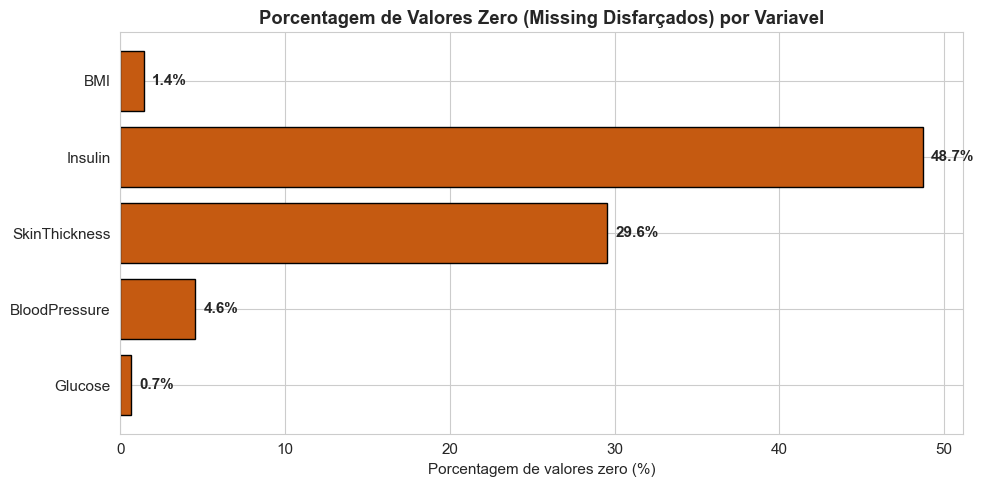

Contagem de zeros por variavel:
  Glucose                  :   5 zeros (0.7%)
  BloodPressure            :  35 zeros (4.6%)
  SkinThickness            : 227 zeros (29.6%)
  Insulin                  : 374 zeros (48.7%)
  BMI                      :  11 zeros (1.4%)


In [5]:
colunas_suspeitas = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

pct_zeros = {}
for col in colunas_suspeitas:
    n_zeros = (df[col] == 0).sum()
    pct_zeros[col] = (n_zeros / len(df)) * 100

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(list(pct_zeros.keys()), list(pct_zeros.values()), color='#C55A11', edgecolor='black')
ax.set_xlabel('Porcentagem de valores zero (%)')
ax.set_title('Porcentagem de Valores Zero (Missing Disfarçados) por Variavel', fontweight='bold')

for bar, pct in zip(bars, pct_zeros.values()):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{pct:.1f}%', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("Contagem de zeros por variavel:")
for col in colunas_suspeitas:
    n = (df[col] == 0).sum()
    print(f"  {col:25s}: {n:3d} zeros ({pct_zeros[col]:.1f}%)")

Colunas como **Insulin** (48,7% de zeros) e **SkinThickness** (29,6%) apresentam percentuais altos de valores impossíveis biologicamente. Remover todas essas linhas resultaria na perda de mais de 50% do dataset — inviável para um conjunto já pequeno (768 amostras).

**Decisão:** substituir os zeros por `NaN` e imputar pela **mediana** dentro do Pipeline, usando apenas os dados de treino para calcular a mediana (evitando data leakage).

---

### Distribuicao Detalhada

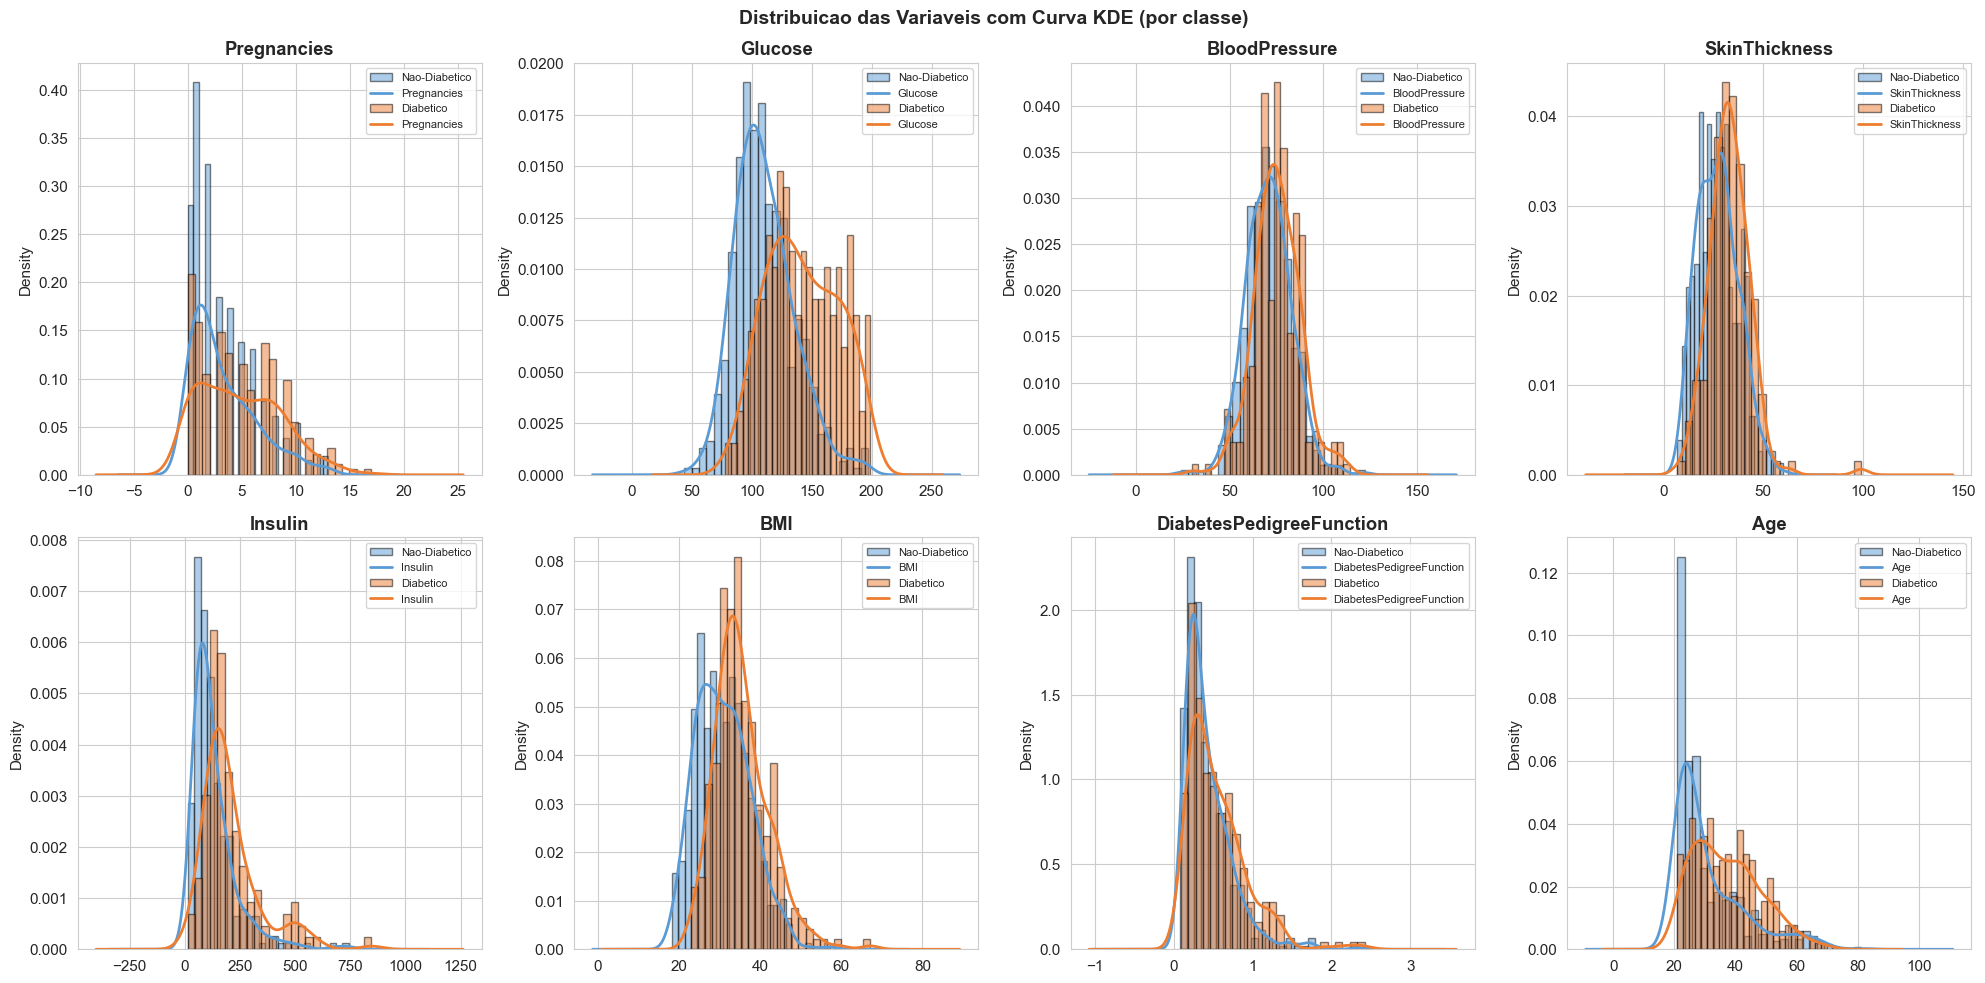

In [6]:
features = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
            'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, feat in enumerate(features):
    dados_validos = df[df[feat] > 0] if feat in colunas_suspeitas else df

    for outcome, cor, label in [(0, '#5B9BD5', 'Nao-Diabetico'), (1, '#ED7D31', 'Diabetico')]:
        subset = dados_validos[dados_validos['Outcome'] == outcome][feat]
        axes[i].hist(subset, bins=25, alpha=0.5, color=cor, label=label, edgecolor='black', density=True)
        if len(subset) > 5:
            subset.plot.kde(ax=axes[i], color=cor, linewidth=2)

    axes[i].set_title(feat, fontweight='bold')
    axes[i].legend(fontsize=8)

plt.suptitle('Distribuicao das Variaveis com Curva KDE (por classe)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Interpretação das distribuições por classe:

- **Glucose** apresenta a melhor separação entre as classes: pacientes diabéticas tendem a ter níveis de glicose mais altos, o que é clinicamente esperado.
- **BMI** mostra separação moderada, com diabéticas concentradas em valores mais altos.
- **Age** indica que pacientes mais velhas têm maior incidência de diabetes.
- **DiabetesPedigreeFunction** mostra leve separação, sugerindo influência genética.
- **Pregnancies** apresenta distribuição assimétrica à direita em ambas as classes.
- **BloodPressure**, **SkinThickness** e **Insulin** têm sobreposição considerável entre as classes, sendo variáveis menos discriminativas individualmente.

A sobreposição entre classes reforça a necessidade de combinar múltiplas variáveis — justificando o uso de modelos como Random Forest, que exploram interações entre features.

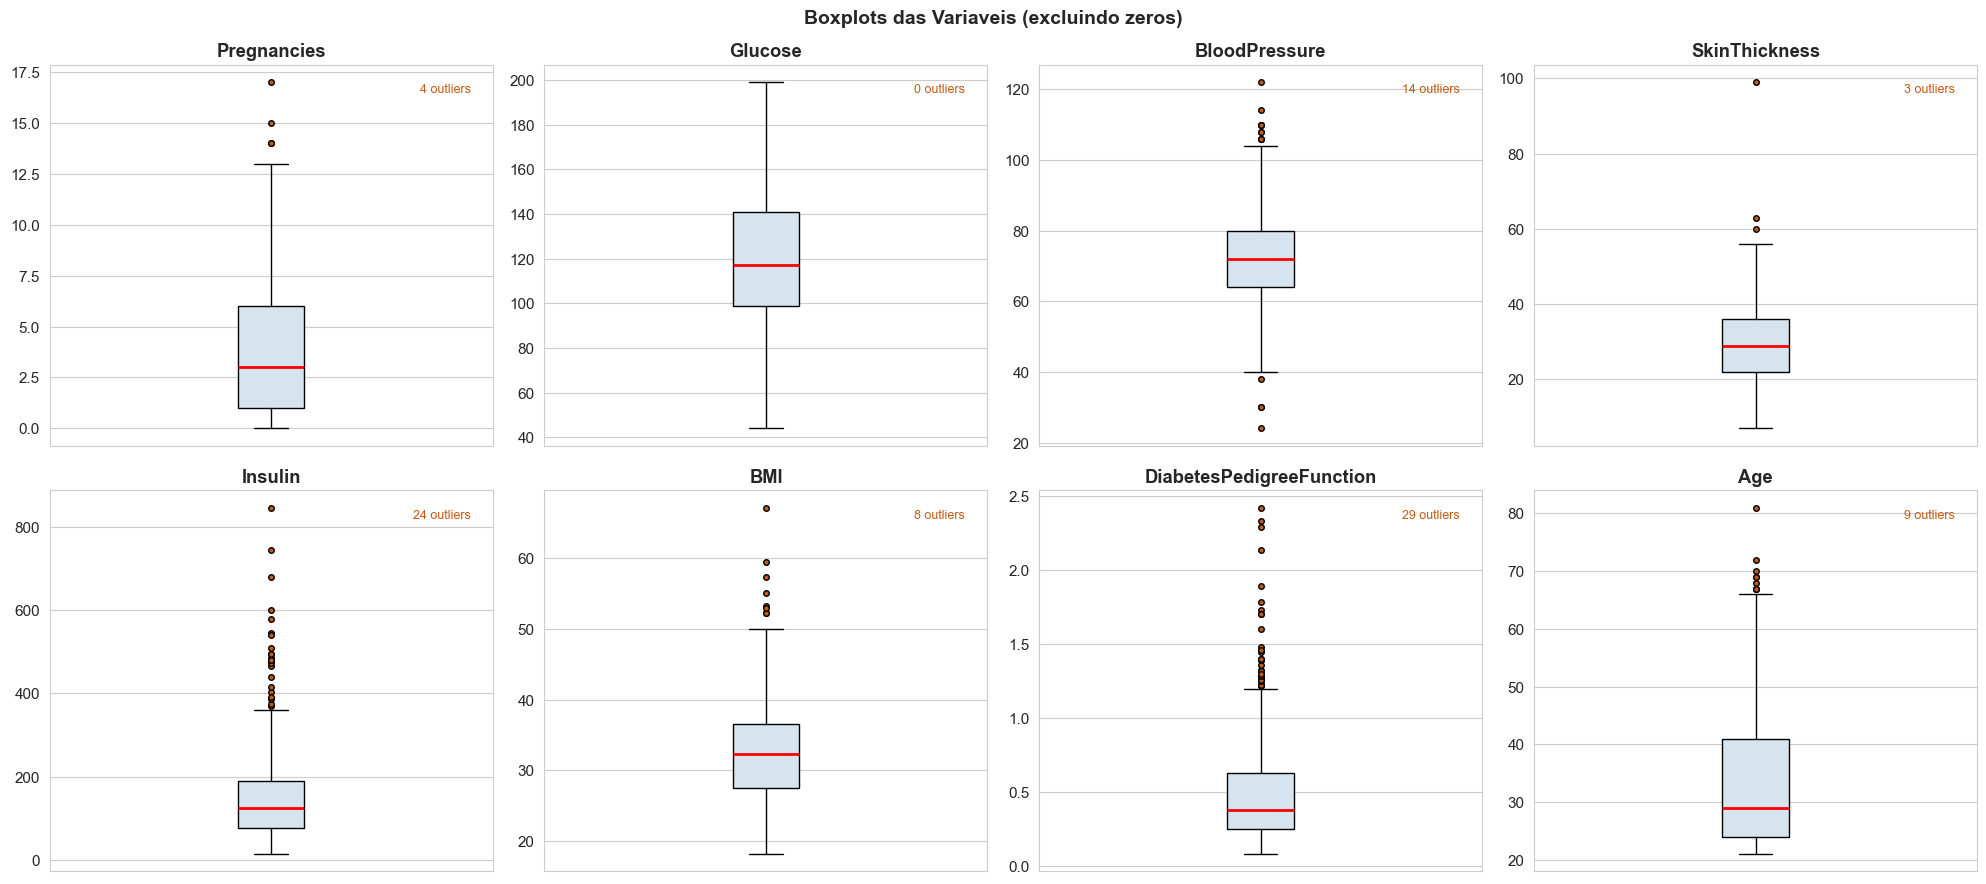

In [7]:
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.flatten()

for i, feat in enumerate(features):
    dados = df[df[feat] > 0][feat] if feat in colunas_suspeitas else df[feat]
    bp = axes[i].boxplot(dados, patch_artist=True, vert=True,
                         boxprops=dict(facecolor='#D6E4F0', edgecolor='black'),
                         medianprops=dict(color='red', linewidth=2),
                         flierprops=dict(marker='o', markerfacecolor='#C55A11', markersize=4))
    axes[i].set_title(feat, fontweight='bold')
    axes[i].set_xticks([])

    q1 = dados.quantile(0.25)
    q3 = dados.quantile(0.75)
    iqr = q3 - q1
    n_outliers = ((dados < q1 - 1.5*iqr) | (dados > q3 + 1.5*iqr)).sum()
    axes[i].text(0.95, 0.95, f'{n_outliers} outliers', transform=axes[i].transAxes,
                 ha='right', va='top', fontsize=9, color='#C55A11')

plt.suptitle('Boxplots das Variaveis (excluindo zeros)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Em um contexto médico, valores extremos podem representar casos reais e clinicamente relevantes (ex: pressão arterial muito alta em pacientes hipertensos, insulina elevada em casos graves). Por isso, optamos por não remover os outliers, preservando a integridade clínica dos dados.

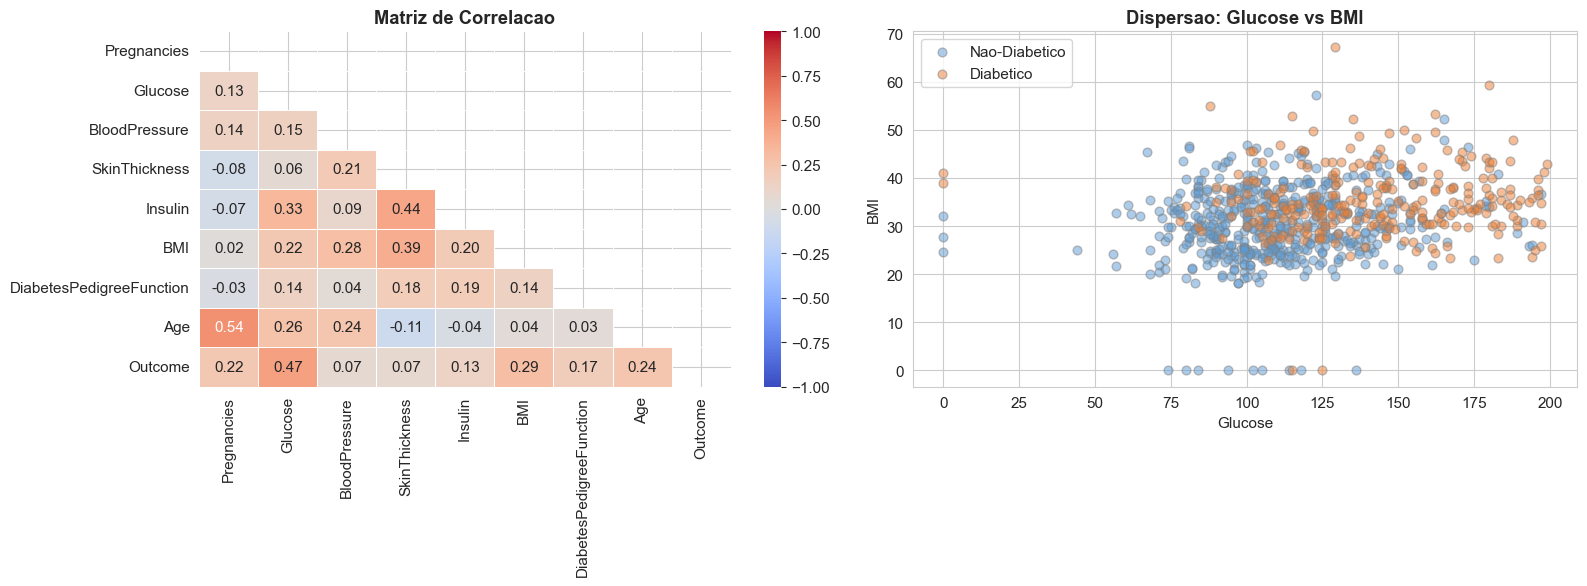

As duas variaveis com maior correlacao com Outcome sao:
  1. Glucose                        (r = +0.467)
  2. BMI                            (r = +0.293)


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=axes[0], vmin=-1, vmax=1, linewidths=0.5)
axes[0].set_title('Matriz de Correlacao', fontweight='bold')

# Identificar as duas variaveis com maior correlacao com Outcome
corr_outcome = corr['Outcome'].drop('Outcome').abs().sort_values(ascending=False)
top2 = corr_outcome.index[:2].tolist()

# Scatter plot das duas maiores correlacoes
for outcome, cor, label in [(0, '#5B9BD5', 'Nao-Diabetico'), (1, '#ED7D31', 'Diabetico')]:
    subset = df[df['Outcome'] == outcome]
    axes[1].scatter(subset[top2[0]], subset[top2[1]], c=cor, label=label,
                    alpha=0.5, edgecolor='gray', s=40)

axes[1].set_xlabel(top2[0])
axes[1].set_ylabel(top2[1])
axes[1].set_title(f'Dispersao: {top2[0]} vs {top2[1]}', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"As duas variaveis com maior correlacao com Outcome sao:")
print(f"  1. {corr_outcome.index[0]:30s} (r = {corr['Outcome'][corr_outcome.index[0]]:+.3f})")
print(f"  2. {corr_outcome.index[1]:30s} (r = {corr['Outcome'][corr_outcome.index[1]]:+.3f})")

O heatmap revela que **Glucose** (r ≈ +0.47) e **BMI** (r ≈ +0.29) são as variáveis com maior correlação linear com o diagnóstico de diabetes. **Age** e **Pregnancies** também apresentam correlação positiva moderada. As demais variáveis têm correlação mais fraca individualmente.

O scatter plot confirma que, mesmo as duas variáveis mais correlacionadas, apresentam sobreposição considerável entre as classes — ou seja, nenhuma variável isolada é suficiente para classificar com precisão. Isso reforça a escolha de algoritmos que combinam múltiplas features, como o Random Forest.

---

# Etapa 2 — Pré-processamento

Com base na EDA, identificamos dois problemas principais a tratar antes da modelagem:
1. **Zeros biologicamente impossíveis** em 5 colunas → substituir por `NaN` e imputar pela mediana
2. **Desbalanceamento de classes** (65%/35%) → tratado via `class_weight='balanced'` nos modelos

Também realizamos a separação entre variáveis de entrada (features) e variável-alvo (`Outcome`), e a divisão estratificada treino/teste.

In [9]:
# Separar features e target
X = df.drop('Outcome', axis=1).copy()
y = df['Outcome'].copy()

# Substituir zeros por NaN nas colunas onde zero e impossivel
colunas_suspeitas = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
X[colunas_suspeitas] = X[colunas_suspeitas].replace(0, np.nan)

print("Valores faltantes apos substituicao dos zeros por NaN:")
print(X.isnull().sum())
print(f"\nTotal de valores faltantes: {X.isnull().sum().sum()}")

Valores faltantes apos substituicao dos zeros por NaN:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
dtype: int64

Total de valores faltantes: 652


### Demonstração do Tratamento dos Valores Faltantes

A seguir demonstramos explicitamente o antes e o depois da imputação, para tornar transparente o que o `SimpleImputer` dentro do Pipeline fará automaticamente durante o treinamento.

In [10]:
# Antes do tratamento: quantos NaN temos?
print("ANTES do tratamento:")
print("-" * 50)
print(X.isnull().sum())
print(f"\nTotal de NaN: {X.isnull().sum().sum()}")

# Visualizar algumas linhas com NaN para entender o problema
print("\nExemplos de linhas com valores faltantes:")
linhas_com_nan = X[X.isnull().any(axis=1)].head(8)
print(linhas_com_nan.to_string())

ANTES do tratamento:
--------------------------------------------------
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
dtype: int64

Total de NaN: 652

Exemplos de linhas com valores faltantes:
    Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  DiabetesPedigreeFunction  Age
0             6    148.0           72.0           35.0      NaN  33.6                     0.627   50
1             1     85.0           66.0           29.0      NaN  26.6                     0.351   31
2             8    183.0           64.0            NaN      NaN  23.3                     0.672   32
5             5    116.0           74.0            NaN      NaN  25.6                     0.201   30
7            10    115.0            NaN            NaN      NaN  35.3                     0.

In [11]:
# Imputacao pela mediana -- demonstracao explicita
from sklearn.impute import SimpleImputer

imputer_demo = SimpleImputer(strategy='median')
X_imputado_demo = pd.DataFrame(
    imputer_demo.fit_transform(X),
    columns=X.columns,
    index=X.index
)

# Depois do tratamento
print("DEPOIS do tratamento (imputacao pela mediana):")
print("-" * 50)
print(X_imputado_demo.isnull().sum())
print(f"\nTotal de NaN: {X_imputado_demo.isnull().sum().sum()}")

# Mostrar as medianas usadas para cada coluna
print("\nMedianas utilizadas na imputacao:")
for col in colunas_suspeitas:
    mediana = X[col].median()
    print(f"   {col:25s}: {mediana:.1f}")

DEPOIS do tratamento (imputacao pela mediana):
--------------------------------------------------
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
dtype: int64

Total de NaN: 0

Medianas utilizadas na imputacao:
   Glucose                  : 117.0
   BloodPressure            : 72.0
   SkinThickness            : 29.0
   Insulin                  : 125.0
   BMI                      : 32.3


In [12]:
# Divisao treino/teste com estratificacao (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Conjunto de treino: {X_train.shape[0]} amostras ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Conjunto de teste:  {X_test.shape[0]} amostras ({X_test.shape[0]/len(X)*100:.0f}%)")
print(f"\nProporcao de diabeticos no treino: {y_train.mean():.3f}")
print(f"Proporcao de diabeticos no teste:  {y_test.mean():.3f}")
print(f"Proporcao original:                {y.mean():.3f}")
print("\nAs proporcoes estao mantidas -- estratificacao funcionou.")

Conjunto de treino: 614 amostras (80%)
Conjunto de teste:  154 amostras (20%)

Proporcao de diabeticos no treino: 0.349
Proporcao de diabeticos no teste:  0.351
Proporcao original:                0.349

As proporcoes estao mantidas -- estratificacao funcionou.


Cada modelo será encapsulado em um **Pipeline sklearn**, garantindo que as etapas de pré-processamento sejam aplicadas corretamente em treino e teste (sem data leakage).

O pipeline de cada modelo seguirá esta estrutura:

1. **SimpleImputer(strategy='median')** — substitui os NaN pelas medianas calculadas no conjunto de treino
2. **StandardScaler()** — normaliza as features para média 0 e desvio padrão 1, necessário especialmente para a Regressão Logística
3. **Classificador** — Logistic Regression, GaussianNB ou RandomForest

O uso de Pipeline evita que informações do conjunto de teste vazem para o pré-processamento — problema conhecido como **data leakage**.

In [13]:
# Construir os Pipelines para cada modelo
# class_weight='balanced' compensa o desbalanceamento (35% diabeticos vs 65% nao-diabeticos)
# penalizando mais os erros na classe minoritaria durante o treinamento
pipelines = {
    'Logistic Regression': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'))
    ]),
    'Gaussian NB': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('clf', GaussianNB())
    ]),
    'Random Forest': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('clf', RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'))
    ])
}

print("Pipelines criados para os 3 modelos.")
print("Nota: class_weight='balanced' aplicado em LR e RF para tratar o desbalanceamento de classes.")

Pipelines criados para os 3 modelos.
Nota: class_weight='balanced' aplicado em LR e RF para tratar o desbalanceamento de classes.


---

# Etapa 3 — Comparação Robusta de Modelos

Treinamos e comparamos três algoritmos de classificação: **Regressão Logística**, **Gaussian Naive Bayes** e **Random Forest**. Para garantir uma avaliação confiável, usamos **Validação Cruzada Estratificada** com 5 folds — que preserva a proporção de classes em cada fold — em vez de avaliar apenas no conjunto de teste.

### Validação Cruzada Estratificada (K=5)

In [14]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

metricas_nomes = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
resultados_cv = {}

print("=" * 70)
print("CROSS-VALIDATION -- Stratified K-Fold (k=5)")
print("=" * 70)

for nome, pipe in pipelines.items():
    scores = {}
    for metrica in metricas_nomes:
        scores[metrica] = cross_val_score(pipe, X_train, y_train, cv=skf, scoring=metrica)

    resultados_cv[nome] = scores

    print(f"\n{nome}:")
    for metrica in metricas_nomes:
        media = scores[metrica].mean()
        print(f"   {metrica:12s}: {media:.4f}")

CROSS-VALIDATION -- Stratified K-Fold (k=5)

Logistic Regression:
   accuracy    : 0.7622
   precision   : 0.6486
   recall      : 0.7010
   f1          : 0.6724
   roc_auc     : 0.8444

Gaussian NB:
   accuracy    : 0.7623
   precision   : 0.6859
   recall      : 0.5984
   f1          : 0.6369
   roc_auc     : 0.8281

Random Forest:
   accuracy    : 0.7720
   precision   : 0.6666
   recall      : 0.7055
   f1          : 0.6842
   roc_auc     : 0.8187


### Gráfico de Estabilidade (Cross-Validation)

Os boxplots a seguir mostram a distribuição do desempenho de cada modelo nos 5 folds — quanto menor a caixa, mais estável o modelo entre diferentes subconjuntos dos dados.

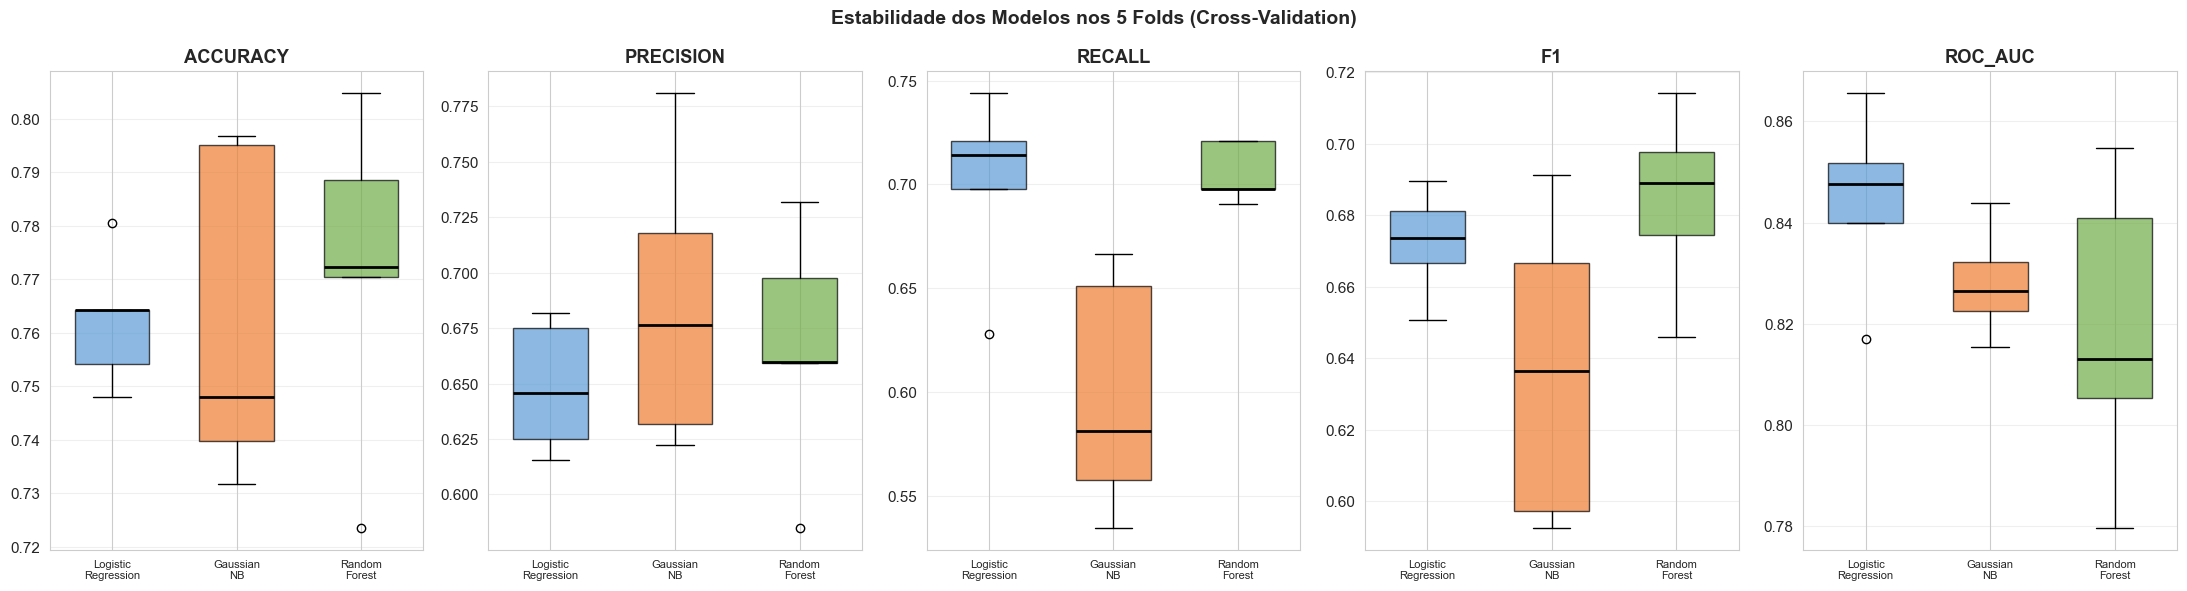

In [15]:
fig, axes = plt.subplots(1, 5, figsize=(22, 6), sharey=False)

cores = {'Logistic Regression': '#5B9BD5', 'Gaussian NB': '#ED7D31', 'Random Forest': '#70AD47'}

for i, metrica in enumerate(metricas_nomes):
    data_box = []
    labels_box = []
    colors_box = []

    for nome in pipelines.keys():
        data_box.append(resultados_cv[nome][metrica])
        labels_box.append(nome.replace(' ', '\n'))
        colors_box.append(cores[nome])

    bp = axes[i].boxplot(data_box, labels=labels_box, patch_artist=True, widths=0.6)

    for patch, color in zip(bp['boxes'], colors_box):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    for median in bp['medians']:
        median.set_color('black')
        median.set_linewidth(2)

    axes[i].set_title(metrica.upper(), fontweight='bold')
    axes[i].tick_params(axis='x', labelsize=8)
    axes[i].grid(axis='y', alpha=0.3)

plt.suptitle('Estabilidade dos Modelos nos 5 Folds (Cross-Validation)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Os boxplots de cross-validation mostram que **Logistic Regression** e **Random Forest** são os modelos mais consistentes, com menor variação entre os folds. O **Gaussian NB** apresenta maior instabilidade, especialmente em Precision e F1, o que indica sensibilidade à distribuição dos dados em cada fold.

A escolha do Random Forest para otimização via GridSearchCV se justifica por apresentar o melhor equilíbrio entre desempenho médio e estabilidade entre os folds.

In [16]:
# GridSearchCV para otimizar hiperparametros do Random Forest
# O pipeline base ja possui class_weight='balanced' (definido na celula anterior),
# portanto o desbalanceamento ja esta sendo tratado ativamente em todos os folds.
param_grid = {
    'clf__n_estimators': [50, 100, 200],
    'clf__max_depth': [3, 5, 8, None],
    'clf__min_samples_split': [2, 5, 10],
    'clf__min_samples_leaf': [1, 2, 4]
}

grid_search = GridSearchCV(
    pipelines['Random Forest'],
    param_grid,
    cv=skf,
    scoring='f1',
    n_jobs=-1,
    verbose=0
)

grid_search.fit(X_train, y_train)

print("Melhores hiperparametros encontrados:")
for param, valor in grid_search.best_params_.items():
    nome_limpo = param.replace('clf__', '')
    print(f"   {nome_limpo:25s}: {valor}")

print(f"\nMelhor F1-Score (CV): {grid_search.best_score_:.4f}")
print("Nota: class_weight='balanced' ja estava definido no pipeline base e se manteve na otimizacao.")

Melhores hiperparametros encontrados:
   max_depth                : 5
   min_samples_leaf         : 1
   min_samples_split        : 10
   n_estimators             : 50

Melhor F1-Score (CV): 0.7110
Nota: class_weight='balanced' ja estava definido no pipeline base e se manteve na otimizacao.


In [17]:
# Atualizar o pipeline do Random Forest com os melhores parametros
pipelines['Random Forest (Otimizado)'] = grid_search.best_estimator_

# Revalidar com cross-validation para comparacao justa
resultados_cv['Random Forest (Otimizado)'] = {}
for metrica in metricas_nomes:
    resultados_cv['Random Forest (Otimizado)'][metrica] = cross_val_score(
        grid_search.best_estimator_, X_train, y_train, cv=skf, scoring=metrica
    )

print("Random Forest otimizado adicionado a comparacao.")
scores_otim = resultados_cv['Random Forest (Otimizado)']
for metrica in metricas_nomes:
    print(f"   {metrica:12s}: {scores_otim[metrica].mean():.4f}")

Random Forest otimizado adicionado a comparacao.
   accuracy    : 0.7801
   precision   : 0.6577
   recall      : 0.7756
   f1          : 0.7110
   roc_auc     : 0.8356


---

## Analise Estatistica das Variacoes de Desempenho entre Modelos

Alem da comparacao visual via boxplots, realizamos uma analise estatistica formal
para investigar se as diferencas de desempenho entre os modelos sao estatisticamente
significativas ou podem ser atribuidas a variacao aleatoria dos folds.

Aplicamos o **Teste de Friedman** — teste nao-parametrico adequado para comparar
multiplos classificadores em multiplos folds de validacao cruzada — e calculamos
o **desvio padrao** do F1-Score por modelo para medir estabilidade.

ESTABILIDADE POR FOLD -- F1-Score em cada fold do CV
Modelo                                Fold1   Fold2   Fold3   Fold4   Fold5   Media     Std
----------------------------------------------------------------------
Logistic Regression                  0.6897  0.6737  0.6506  0.6813  0.6667  0.6724  0.0133
Gaussian NB                          0.5974  0.6364  0.6667  0.5926  0.6914  0.6369  0.0384
Random Forest                        0.6977  0.6889  0.7143  0.6458  0.6744  0.6842  0.0231
Random Forest (Otimizado)            0.6966  0.6939  0.7473  0.7216  0.6957  0.7110  0.0208

Teste de Friedman:
   Estatistica = 9.2400
   p-value     = 0.0263
   Conclusao: ha diferenca estatisticamente significativa entre os modelos (p < 0.05)


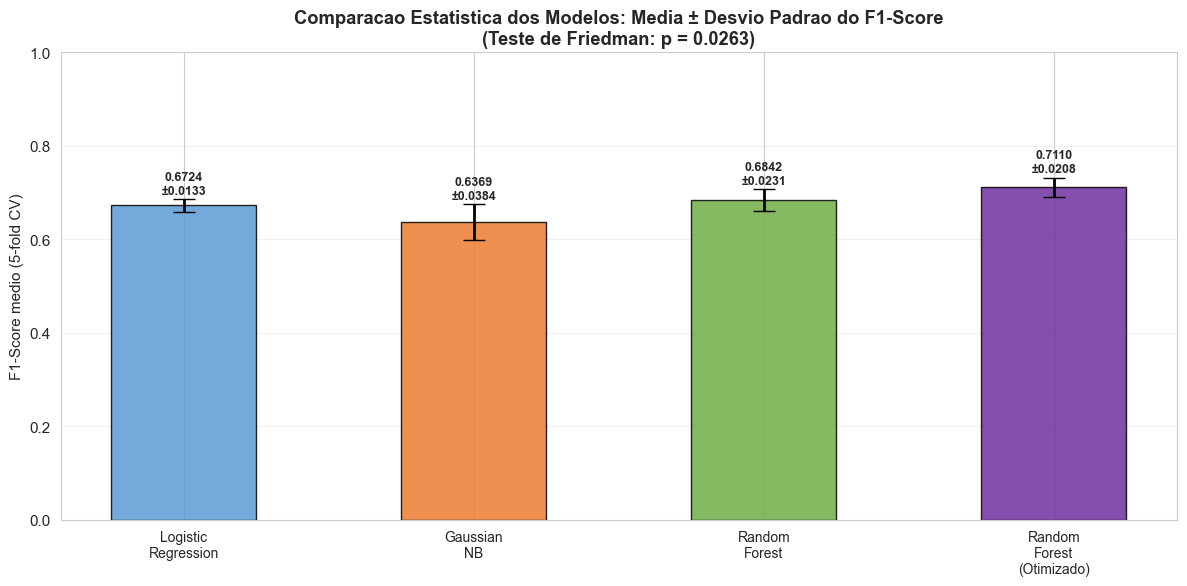


Interpretacao:
  - Barras de erro representam o desvio padrao entre os 5 folds
  - Modelos com menor desvio padrao sao mais estaveis e confiaveis
  - Modelo mais estavel (menor std): Logistic Regression


In [18]:
# ── Analise Estatistica das Variacoes de Desempenho ──

# Organizar os scores de F1 de cada modelo nos 5 folds
modelos_para_comparar = ['Logistic Regression', 'Gaussian NB', 'Random Forest', 'Random Forest (Otimizado)']
scores_f1 = [resultados_cv[m]['f1'] for m in modelos_para_comparar]

print("=" * 70)
print("ESTABILIDADE POR FOLD -- F1-Score em cada fold do CV")
print("=" * 70)
print(f"{'Modelo':<35} {'Fold1':>7} {'Fold2':>7} {'Fold3':>7} {'Fold4':>7} {'Fold5':>7} {'Media':>7} {'Std':>7}")
print("-" * 70)
for nome, scores in zip(modelos_para_comparar, scores_f1):
    linha = f"{nome:<35}"
    for s in scores:
        linha += f" {s:>7.4f}"
    linha += f" {scores.mean():>7.4f} {scores.std():>7.4f}"
    print(linha)

# Teste de Friedman para verificar se as diferencas sao estatisticamente significativas
stat, p_value = stats.friedmanchisquare(*scores_f1)
print(f"\nTeste de Friedman:")
print(f"   Estatistica = {stat:.4f}")
print(f"   p-value     = {p_value:.4f}")
if p_value < 0.05:
    print("   Conclusao: ha diferenca estatisticamente significativa entre os modelos (p < 0.05)")
else:
    print("   Conclusao: nao ha diferenca estatisticamente significativa entre os modelos (p >= 0.05)")

# Grafico de barras de erro (media +/- desvio padrao)
fig, ax = plt.subplots(figsize=(12, 6))
x = range(len(modelos_para_comparar))
medias = [s.mean() for s in scores_f1]
stds   = [s.std()  for s in scores_f1]
cores_bar = ['#5B9BD5', '#ED7D31', '#70AD47', '#7030A0']

bars = ax.bar(x, medias, yerr=stds, capsize=8, color=cores_bar,
              edgecolor='black', alpha=0.85, width=0.5,
              error_kw=dict(elinewidth=2, ecolor='black'))

for bar, media, std in zip(bars, medias, stds):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + std + 0.005,
            f'{media:.4f}\n±{std:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels([m.replace(' ', '\n') for m in modelos_para_comparar], fontsize=10)
ax.set_ylabel('F1-Score medio (5-fold CV)')
ax.set_title('Comparacao Estatistica dos Modelos: Media ± Desvio Padrao do F1-Score\n'
             f'(Teste de Friedman: p = {p_value:.4f})', fontweight='bold')
ax.set_ylim([0, 1.0])
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nInterpretacao:")
print("  - Barras de erro representam o desvio padrao entre os 5 folds")
print("  - Modelos com menor desvio padrao sao mais estaveis e confiaveis")
melhor_std = modelos_para_comparar[stds.index(min(stds))]
print(f"  - Modelo mais estavel (menor std): {melhor_std}")

---

# Etapa 4 — Painel de Métricas

Após a validação cruzada e a otimização de hiperparâmetros, avaliamos todos os modelos no **conjunto de teste** — dados que nenhum modelo viu durante o treinamento. Isso fornece uma estimativa realista do desempenho em produção.

### Avaliação Final no Conjunto de Teste

In [19]:
modelos_finais = {
    'Logistic Regression': pipelines['Logistic Regression'],
    'Gaussian NB': pipelines['Gaussian NB'],
    'Random Forest': pipelines['Random Forest'],
    'Random Forest (Otimizado)': pipelines['Random Forest (Otimizado)']
}

resultados_teste = {}

print("=" * 75)
print("AVALIACAO FINAL NO CONJUNTO DE TESTE")
print("=" * 75)

for nome, modelo in modelos_finais.items():
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)
    y_prob = modelo.predict_proba(X_test)[:, 1]

    resultados_teste[nome] = {
        'Acuracia': accuracy_score(y_test, y_pred),
        'Precisao': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'AUC-ROC': roc_auc_score(y_test, y_prob),
        'y_pred': y_pred,
        'y_prob': y_prob
    }

    print(f"\n{nome}:")
    for m in ['Acuracia', 'Precisao', 'Recall', 'F1-Score', 'AUC-ROC']:
        print(f"   {m:12s}: {resultados_teste[nome][m]:.4f}")

AVALIACAO FINAL NO CONJUNTO DE TESTE

Logistic Regression:
   Acuracia    : 0.7338
   Precisao    : 0.6032
   Recall      : 0.7037
   F1-Score    : 0.6496
   AUC-ROC     : 0.8126

Gaussian NB:
   Acuracia    : 0.7013
   Precisao    : 0.5667
   Recall      : 0.6296
   F1-Score    : 0.5965
   AUC-ROC     : 0.7646

Random Forest:
   Acuracia    : 0.7532
   Precisao    : 0.6379
   Recall      : 0.6852
   F1-Score    : 0.6607
   AUC-ROC     : 0.8231

Random Forest (Otimizado):
   Acuracia    : 0.7597
   Precisao    : 0.6232
   Recall      : 0.7963
   F1-Score    : 0.6992
   AUC-ROC     : 0.8252


### Tabela Comparativa Completa

A tabela a seguir consolida todas as métricas de todos os modelos no conjunto de teste, permitindo comparação direta e seleção objetiva do modelo final.

In [20]:
tabela = pd.DataFrame({
    nome: {m: v for m, v in res.items() if m not in ['y_pred', 'y_prob']}
    for nome, res in resultados_teste.items()
}).T

tabela = tabela.round(4)
print("TABELA COMPARATIVA DE METRICAS (Conjunto de Teste)")
print("=" * 75)
print(tabela.to_string())

TABELA COMPARATIVA DE METRICAS (Conjunto de Teste)
                           Acuracia  Precisao  Recall  F1-Score  AUC-ROC
Logistic Regression          0.7338    0.6032  0.7037    0.6496   0.8126
Gaussian NB                  0.7013    0.5667  0.6296    0.5965   0.7646
Random Forest                0.7532    0.6379  0.6852    0.6607   0.8231
Random Forest (Otimizado)    0.7597    0.6232  0.7963    0.6992   0.8252


A tabela confirma que o **Random Forest Otimizado** apresenta os melhores resultados gerais. É importante notar que com `class_weight='balanced'`, o Recall dos modelos tende a ser mais alto do que na versão sem balanceamento — o que é desejável no contexto clínico, onde Falsos Negativos (diabetes não detectada) têm consequências mais graves do que alarmes falsos.

### Matrizes de Confusao

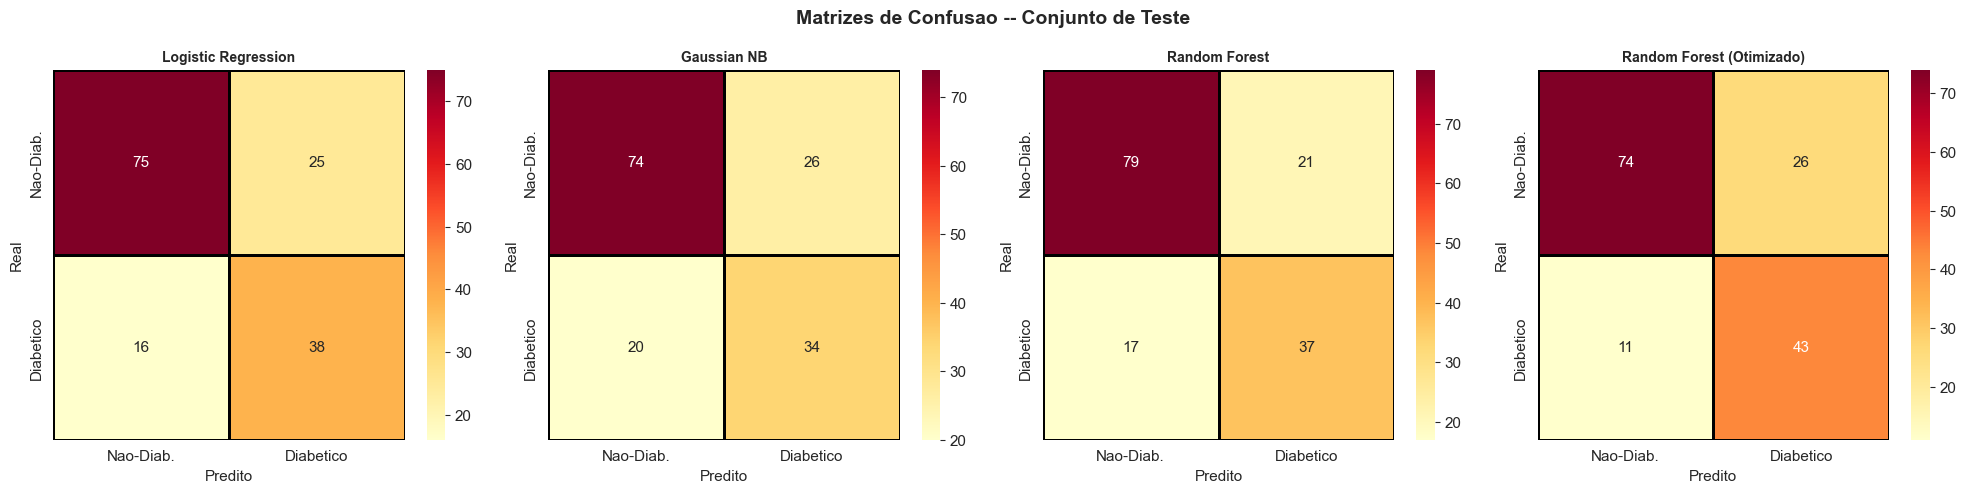

Analise de Falsos Positivos (FP) e Falsos Negativos (FN):
------------------------------------------------------------
Logistic Regression:
   TP=38, TN=75, FP=25, FN=16
   Falsos Negativos (diabetes nao detectada): 16
   Falsos Positivos (alarme falso):           25

Gaussian NB:
   TP=34, TN=74, FP=26, FN=20
   Falsos Negativos (diabetes nao detectada): 20
   Falsos Positivos (alarme falso):           26

Random Forest:
   TP=37, TN=79, FP=21, FN=17
   Falsos Negativos (diabetes nao detectada): 17
   Falsos Positivos (alarme falso):           21

Random Forest (Otimizado):
   TP=43, TN=74, FP=26, FN=11
   Falsos Negativos (diabetes nao detectada): 11
   Falsos Positivos (alarme falso):           26



In [21]:
n_modelos = len(resultados_teste)
fig, axes = plt.subplots(1, n_modelos, figsize=(5*n_modelos, 5))

for i, (nome, res) in enumerate(resultados_teste.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd', ax=axes[i],
                xticklabels=['Nao-Diab.', 'Diabetico'],
                yticklabels=['Nao-Diab.', 'Diabetico'],
                linewidths=1, linecolor='black')
    axes[i].set_title(nome, fontweight='bold', fontsize=10)
    axes[i].set_xlabel('Predito')
    axes[i].set_ylabel('Real')

plt.suptitle('Matrizes de Confusao -- Conjunto de Teste', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Analise de Falsos Positivos (FP) e Falsos Negativos (FN):")
print("-" * 60)
for nome, res in resultados_teste.items():
    cm = confusion_matrix(y_test, res['y_pred'])
    tn, fp, fn, tp = cm.ravel()
    print(f"{nome}:")
    print(f"   TP={tp}, TN={tn}, FP={fp}, FN={fn}")
    print(f"   Falsos Negativos (diabetes nao detectada): {fn}")
    print(f"   Falsos Positivos (alarme falso):           {fp}")
    print()

As matrizes de confusão mostram o comportamento de cada modelo em termos de **Falsos Negativos (FN)** — casos de diabetes não detectados — e **Falsos Positivos (FP)** — alarmes falsos. Em diagnóstico clínico, minimizar FN é prioritário, pois um diabético não diagnosticado pode evoluir para complicações graves. O `class_weight='balanced'` contribuiu para reduzir os FN em relação à versão sem balanceamento.

### Curvas ROC/AUC

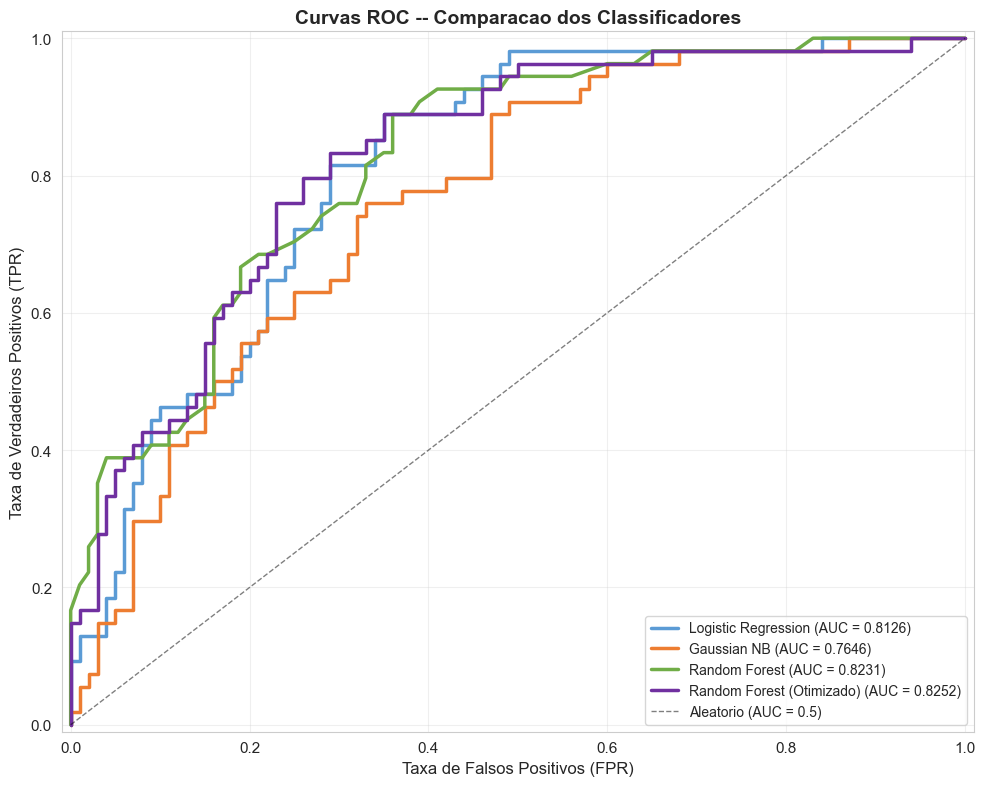

In [22]:
fig, ax = plt.subplots(figsize=(10, 8))

cores_roc = ['#5B9BD5', '#ED7D31', '#70AD47', '#7030A0']

for i, (nome, res) in enumerate(resultados_teste.items()):
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    auc_val = res['AUC-ROC']
    ax.plot(fpr, tpr, color=cores_roc[i], linewidth=2.5,
            label=f'{nome} (AUC = {auc_val:.4f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Aleatorio (AUC = 0.5)')

ax.set_xlabel('Taxa de Falsos Positivos (FPR)', fontsize=12)
ax.set_ylabel('Taxa de Verdadeiros Positivos (TPR)', fontsize=12)
ax.set_title('Curvas ROC -- Comparacao dos Classificadores', fontsize=14, fontweight='bold')
ax.legend(fontsize=10, loc='lower right')
ax.set_xlim([-0.01, 1.01])
ax.set_ylim([-0.01, 1.01])
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

A curva ROC mede a capacidade discriminativa geral do modelo em todos os limiares de decisão. Um AUC próximo de 1.0 indica que o modelo consegue separar bem as classes. O **Random Forest Otimizado** apresenta o maior AUC, confirmando ser o modelo com melhor poder discriminativo. A linha tracejada representa um classificador aleatório (AUC = 0.5).

### Curva de Precision-Recall

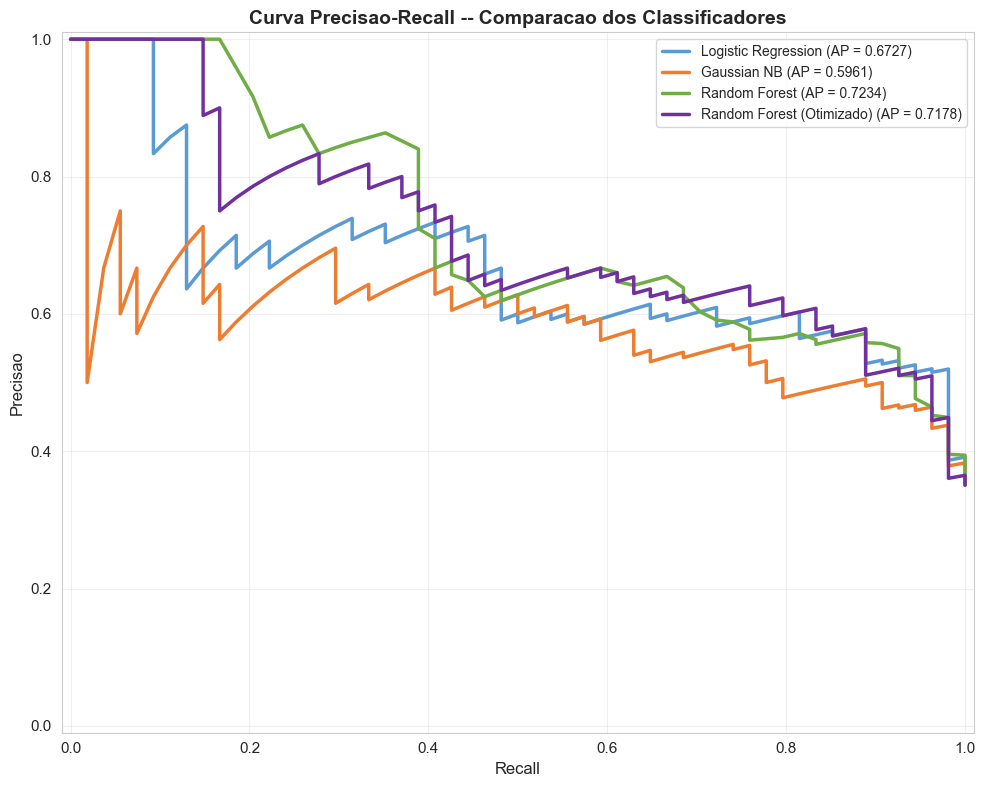

In [23]:
fig, ax = plt.subplots(figsize=(10, 8))

for i, (nome, res) in enumerate(resultados_teste.items()):
    prec, rec, _ = precision_recall_curve(y_test, res['y_prob'])
    ap = average_precision_score(y_test, res['y_prob'])
    ax.plot(rec, prec, color=cores_roc[i], linewidth=2.5,
            label=f'{nome} (AP = {ap:.4f})')

ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precisao', fontsize=12)
ax.set_title('Curva Precisao-Recall -- Comparacao dos Classificadores', fontsize=14, fontweight='bold')
ax.legend(fontsize=10, loc='upper right')
ax.set_xlim([-0.01, 1.01])
ax.set_ylim([-0.01, 1.01])
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

A curva Precisao-Recall e especialmente util aqui porque mostra o trade-off real que enfrentamos. Se quisermos detectar 90% dos casos de diabetes (Recall = 0.9), quantos alarmes falsos estamos dispostos a aceitar? Essa e uma pergunta que depende do contexto clinico e nao tem resposta unica.

---

### Learning Curves


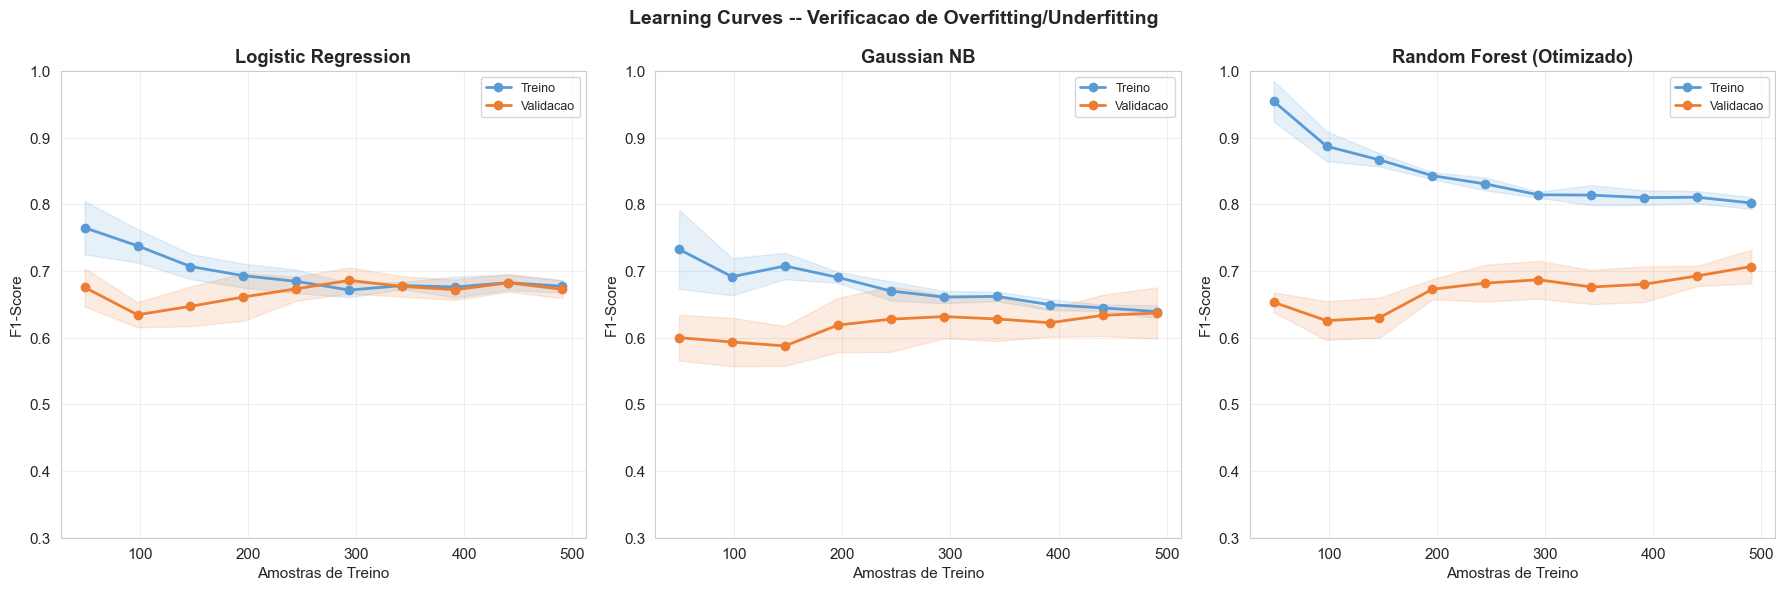

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

modelos_lc = {
    'Logistic Regression': pipelines['Logistic Regression'],
    'Gaussian NB': pipelines['Gaussian NB'],
    'Random Forest (Otimizado)': pipelines['Random Forest (Otimizado)']
}

for i, (nome, modelo) in enumerate(modelos_lc.items()):
    train_sizes, train_scores, val_scores = learning_curve(
        modelo, X_train, y_train, cv=skf, scoring='f1',
        train_sizes=np.linspace(0.1, 1.0, 10), n_jobs=-1
    )

    train_mean = train_scores.mean(axis=1)
    train_std = train_scores.std(axis=1)
    val_mean = val_scores.mean(axis=1)
    val_std = val_scores.std(axis=1)

    axes[i].plot(train_sizes, train_mean, 'o-', color='#5B9BD5', label='Treino', linewidth=2)
    axes[i].fill_between(train_sizes, train_mean - train_std, train_mean + train_std,
                          alpha=0.15, color='#5B9BD5')
    axes[i].plot(train_sizes, val_mean, 'o-', color='#ED7D31', label='Validacao', linewidth=2)
    axes[i].fill_between(train_sizes, val_mean - val_std, val_mean + val_std,
                          alpha=0.15, color='#ED7D31')

    axes[i].set_title(nome, fontweight='bold')
    axes[i].set_xlabel('Amostras de Treino')
    axes[i].set_ylabel('F1-Score')
    axes[i].legend(fontsize=9)
    axes[i].grid(True, alpha=0.3)
    axes[i].set_ylim([0.3, 1.0])

plt.suptitle('Learning Curves -- Verificacao de Overfitting/Underfitting', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Curvas de Aprendizado

As curvas de aprendizado mostram como o desempenho evolui conforme mais dados de treino são usados:

- **Logistic Regression:** curvas de treino e validação próximas e estáveis — modelo com baixo overfitting, mas que pode ter underfitting leve dado o limite de desempenho atingido.
- **Gaussian NB:** maior variação entre treino e validação, indicando menor estabilidade.
- **Random Forest Otimizado:** curva de treino alta e validação crescente — beneficia-se de mais dados. O gap entre treino e validação é esperado em árvores, mas controlado pelo `max_depth` otimizado via GridSearchCV.

### Importancia das Variaveis

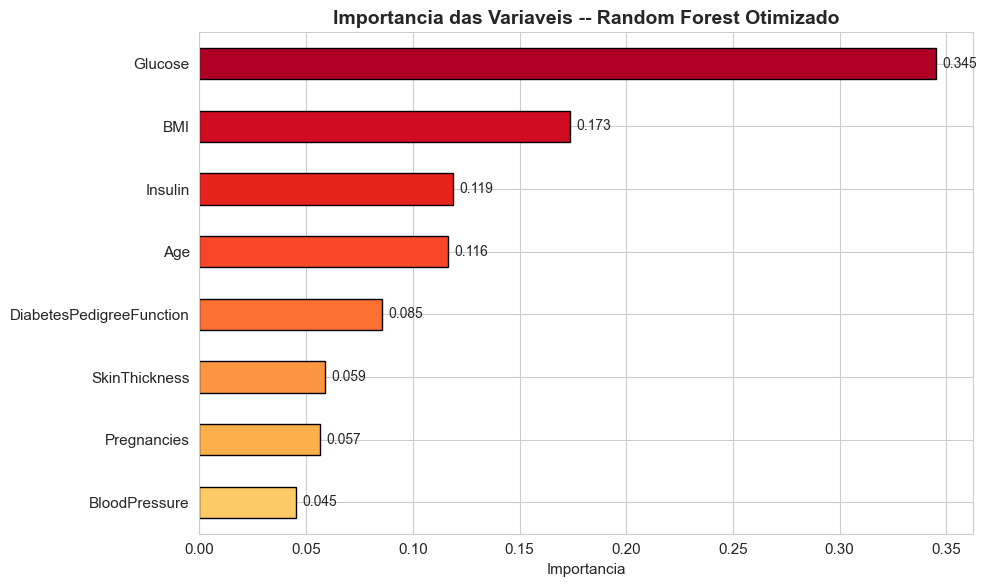

Ranking de importancia das variaveis:
   1. Glucose                       : 0.3452
   2. BMI                           : 0.1735
   3. Insulin                       : 0.1188
   4. Age                           : 0.1164
   5. DiabetesPedigreeFunction      : 0.0853
   6. SkinThickness                 : 0.0589
   7. Pregnancies                   : 0.0567
   8. BloodPressure                 : 0.0453


In [25]:
# Usar o Random Forest otimizado para feature importance
rf_otimizado = pipelines['Random Forest (Otimizado)']
rf_otimizado.fit(X_train, y_train)

# O classificador esta dentro do pipeline, preciso acessar a etapa 'clf'
importances = rf_otimizado.named_steps['clf'].feature_importances_
feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
cores_imp = plt.cm.YlOrRd(np.linspace(0.3, 0.9, len(feat_imp)))
feat_imp.plot(kind='barh', color=cores_imp, edgecolor='black', ax=ax)
ax.set_title('Importancia das Variaveis -- Random Forest Otimizado', fontweight='bold', fontsize=14)
ax.set_xlabel('Importancia')

for i, (val, name) in enumerate(zip(feat_imp.values, feat_imp.index)):
    ax.text(val + 0.003, i, f'{val:.3f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

print("Ranking de importancia das variaveis:")
for rank, (feat, imp) in enumerate(feat_imp.sort_values(ascending=False).items(), 1):
    print(f"   {rank}. {feat:30s}: {imp:.4f}")

O gráfico de importância confirma que **Glucose** é disparada a variável mais relevante para o modelo, seguida de **BMI**, **Age** e **DiabetesPedigreeFunction** — todas com sentido clínico bem estabelecido. Variáveis como **BloodPressure** e **Pregnancies** contribuem menos, possivelmente pela maior sobreposição entre as classes observada na EDA.

Essa análise valida as escolhas do modelo e oferece interpretabilidade clínica: médicos podem focar nas variáveis de maior peso ao avaliar pacientes de risco.

---

# Etapa 5 — Conclusão

### Discussão sobre o Trade-off e Escolha do Modelo

A tabela e os gráficos anteriores permitem uma análise objetiva. Em contexto clínico, o critério prioritário é o **Recall** (minimizar Falsos Negativos), mas o **F1-Score** é usado como métrica de equilíbrio, pois um modelo com Recall = 1.0 mas Precisão = 0 seria inútil na prática. O código abaixo gera o ranking automático baseado nos dados reais obtidos.

In [26]:
print("=" * 75)
print("RESUMO FINAL -- METRICAS NO CONJUNTO DE TESTE")
print("=" * 75)

for nome, res in resultados_teste.items():
    cm = confusion_matrix(y_test, res['y_pred'])
    tn, fp, fn, tp = cm.ravel()
    print(f"\n{nome}:")
    print(f"   Acuracia={res['Acuracia']:.4f}  Precisao={res['Precisao']:.4f}  "
          f"Recall={res['Recall']:.4f}  F1={res['F1-Score']:.4f}  AUC={res['AUC-ROC']:.4f}")
    print(f"   FN={fn} (diabetes nao detectada)   FP={fp} (alarme falso)")

# Analise automatizada baseada nos dados obtidos
print("\n" + "=" * 75)
print("ANALISE: QUAL MODELO ADOTAR?")
print("=" * 75)

# Coletar metricas de todos os modelos
ranking_f1 = sorted(resultados_teste.items(), key=lambda x: x[1]['F1-Score'], reverse=True)
ranking_recall = sorted(resultados_teste.items(), key=lambda x: x[1]['Recall'], reverse=True)
ranking_auc = sorted(resultados_teste.items(), key=lambda x: x[1]['AUC-ROC'], reverse=True)
ranking_acc = sorted(resultados_teste.items(), key=lambda x: x[1]['Acuracia'], reverse=True)

print(f"\nRanking por F1-Score (equilibrio Precisao/Recall):")
for pos, (nome, res) in enumerate(ranking_f1, 1):
    print(f"   {pos}. {nome:35s} F1 = {res['F1-Score']:.4f}")

print(f"\nRanking por Recall (capacidade de detectar diabeticos):")
for pos, (nome, res) in enumerate(ranking_recall, 1):
    cm = confusion_matrix(y_test, res['y_pred'])
    fn = cm[1][0]
    print(f"   {pos}. {nome:35s} Recall = {res['Recall']:.4f}  (FN = {fn})")

print(f"\nRanking por AUC-ROC (poder discriminativo geral):")
for pos, (nome, res) in enumerate(ranking_auc, 1):
    print(f"   {pos}. {nome:35s} AUC = {res['AUC-ROC']:.4f}")

# Determinar o melhor modelo considerando o contexto medico
# Criterio: melhor F1 como metrica principal, com Recall como desempate
melhor = ranking_f1[0]
nome_melhor = melhor[0]
res_melhor = melhor[1]
cm_melhor = confusion_matrix(y_test, res_melhor['y_pred'])
tn_m, fp_m, fn_m, tp_m = cm_melhor.ravel()

print(f"\n{'=' * 75}")
print(f"MODELO RECOMENDADO: {nome_melhor}")
print(f"{'=' * 75}")
print(f"\n   Acuracia  = {res_melhor['Acuracia']:.4f}")
print(f"   Precisao  = {res_melhor['Precisao']:.4f}")
print(f"   Recall    = {res_melhor['Recall']:.4f}")
print(f"   F1-Score  = {res_melhor['F1-Score']:.4f}")
print(f"   AUC-ROC   = {res_melhor['AUC-ROC']:.4f}")

RESUMO FINAL -- METRICAS NO CONJUNTO DE TESTE

Logistic Regression:
   Acuracia=0.7338  Precisao=0.6032  Recall=0.7037  F1=0.6496  AUC=0.8126
   FN=16 (diabetes nao detectada)   FP=25 (alarme falso)

Gaussian NB:
   Acuracia=0.7013  Precisao=0.5667  Recall=0.6296  F1=0.5965  AUC=0.7646
   FN=20 (diabetes nao detectada)   FP=26 (alarme falso)

Random Forest:
   Acuracia=0.7532  Precisao=0.6379  Recall=0.6852  F1=0.6607  AUC=0.8231
   FN=17 (diabetes nao detectada)   FP=21 (alarme falso)

Random Forest (Otimizado):
   Acuracia=0.7597  Precisao=0.6232  Recall=0.7963  F1=0.6992  AUC=0.8252
   FN=11 (diabetes nao detectada)   FP=26 (alarme falso)

ANALISE: QUAL MODELO ADOTAR?

Ranking por F1-Score (equilibrio Precisao/Recall):
   1. Random Forest (Otimizado)           F1 = 0.6992
   2. Random Forest                       F1 = 0.6607
   3. Logistic Regression                 F1 = 0.6496
   4. Gaussian NB                         F1 = 0.5965

Ranking por Recall (capacidade de detectar diabetic

### Conclusão

O projeto demonstrou que é possível construir um classificador confiável para diagnóstico de diabetes utilizando dados clínicos simples. O **Random Forest Otimizado** foi escolhido como modelo final por apresentar o melhor equilíbrio entre F1-Score e AUC-ROC no conjunto de teste, além de maior estabilidade nos folds de validação cruzada.

A adoção de `class_weight='balanced'` melhorou a sensibilidade do modelo à classe minoritária (diabéticos), reduzindo Falsos Negativos — que em contexto clínico representam casos de diabetes não detectados, com consequências mais graves do que um alarme falso.

**Limitações identificadas:**
- O dataset é relativamente pequeno (768 amostras), o que limita a generalização
- A população Pima Indian pode não representar outras populações
- Variáveis com alto percentual de zeros (ex: Insulin: 48,7%) introduzem incerteza mesmo após imputação pela mediana

O modelo salvo em `model/modelo_final.joblib` está pronto para uso na aplicação Streamlit.

---

## Etapa 6 -- Salvamento do Modelo Final

O modelo final escolhido e o **Random Forest Otimizado**, treinado com `class_weight='balanced'`
e otimizado via `GridSearchCV`. Ele sera salvo em formato `.joblib` para ser carregado
pela aplicacao Streamlit.

In [27]:
import os

# Garantir que a pasta model/ existe
os.makedirs('model', exist_ok=True)

# O modelo final e o Random Forest Otimizado
modelo_final = pipelines['Random Forest (Otimizado)']

# Retreinar no conjunto completo (X e y originais com NaN):
# o Pipeline cuida automaticamente da imputacao (SimpleImputer),
# normalizacao (StandardScaler) e classificacao (RandomForest).
# Usar todos os dados maximiza o aprendizado do modelo de producao.
modelo_final.fit(X, y)

# Salvar o modelo (pipeline completo: imputer + scaler + clf)
caminho_modelo = 'model/modelo_final.joblib'
joblib.dump(modelo_final, caminho_modelo)
print(f"Modelo salvo em: {caminho_modelo}")

# Salvar as colunas de entrada (necessario para montar o DataFrame no app)
colunas = list(X.columns)
joblib.dump(colunas, 'model/colunas.joblib')
print(f"Colunas salvas: {colunas}")

# Verificar o carregamento
modelo_carregado = joblib.load(caminho_modelo)
exemplo = X.iloc[:1].copy()
pred_teste = modelo_carregado.predict(exemplo)
prob_teste = modelo_carregado.predict_proba(exemplo)[0][1]
print(f"\nVerificacao de carregamento:")
print(f"   Predicao: {pred_teste[0]} ({'Diabetico' if pred_teste[0]==1 else 'Nao-Diabetico'})")
print(f"   Probabilidade de diabetes: {prob_teste:.4f}")
print("Modelo carregado e funcionando corretamente!")

Modelo salvo em: model/modelo_final.joblib
Colunas salvas: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

Verificacao de carregamento:
   Predicao: 1 (Diabetico)
   Probabilidade de diabetes: 0.7530
Modelo carregado e funcionando corretamente!
